In [1]:
import utils
import pandas as pd
from pathlib import Path
from collections import defaultdict 
import json
import matplotlib.pyplot as plt

In [2]:
# make a dictionary with key = drug, values = targets
drug_table = pd.read_excel(Path("../data/drugs_with_targets.xlsx"))

drug_t = (
    drug_table
        .dropna(subset=[drug_table.columns[2], drug_table.columns[3]])
        .assign(Genes=lambda df: df.iloc[:, 3].str.split(";"))
        .explode("Genes")
        .assign(Genes=lambda df: df["Genes"].str.strip())
        .groupby(drug_table.columns[2])["Genes"]
        .unique()
        .apply(list)
        .to_dict()
)

In [3]:
# transform into a dictionary where for each gene we have the corresponding drugs
dict_genes = defaultdict(set)

for drug, genes_list in drug_t.items():
    for genes in genes_list:
        for gene in genes.split(","):
            gene = gene.strip()
            if gene:
                dict_genes[gene].add(drug)

dict_genes = {g: ",".join(sorted(d)) for g, d in dict_genes.items()}

In [4]:
# read patients lists (primary, secondary, and all for primary)
patient_ids = pd.read_csv("../data/PatientIds.txt", header=None).iloc[:, 0].tolist()

In [5]:
#function to extract the filename and the run
def parse_filename(f):
    
    if len(f) >= 38: 
        part1 = f[:36]
        part2 = f[37:]
    else: 
        part1 = f[:3]
        part2 = f[4:]

    return part1, part2

In [6]:
# create a dictionary with key=cases, and values contains information like run, control nodes, proteins controlled, drugs
# filter the .json data to remain only with the data where control nodes that have drugs which act on them and can control more than two proteins

path =  Path("../data/AnalysesFromUpWithoutDown-InBetween1-MaxPath3")

row_dict = defaultdict(list)

for filename in path.glob("*.json"):
    with open(filename, "r") as f:
        content = json.load(f)

    target_to_proteins = defaultdict(set)

    for solution in content.get("Solutions", {}).get("Solutions", []):
        for path_entry in solution.get("Paths", []):
            source = path_entry[0]
            target = path_entry[-1]
            target_to_proteins[source].add(target)
            
    just_filename = filename.stem
    file_id, file_label = parse_filename(just_filename)

    for gene, targets in target_to_proteins.items():
        if gene in dict_genes and len(targets) > 2:
            targets_str = " , ".join(sorted(targets))
            row_dict[file_id].append(
                (
                    file_id,
                    file_label,
                    gene,
                    targets_str,
                    len(targets),
                    dict_genes[gene],
                )
            )

In [7]:
# transform the dictionary so that we have separate information for each drug in each case
def patient_drug_p(patient_list, drug_t, row_dict):
    
    patient_drug_protein = defaultdict(list)
    drug_set = set(drug_t.keys())
    
    for patient, rows in row_dict.items():
        for row in rows:
            drugs_in_row = {d.strip() for d in row[5].split(",")}

            for drug in drug_set & drugs_in_row:
                patient_drug_protein[patient].append(
                    (
                        patient,
                        drug,
                        row[1],
                        row[2],
                        row[3],
                        #row[4]
                    )
                )

    return patient_drug_protein
patient_res = patient_drug_p(utils.patient_ids,drug_t,row_dict)

In [8]:
#function to format strings and lists
def to_list_clean(x):
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]
    if isinstance(x, str):
        return [v.strip() for v in x.split(",") if v.strip()]
    return []
    
# generate per-patient drug reports where each drug appears once per patient; control nodes and patient proteins are aggregated across all runs
def report_one_patient(patient_drug_protein, file_name):
    
    summary_df = pd.DataFrame()

    with pd.ExcelWriter(file_name, engine="xlsxwriter") as writer_summary:
        for file_id, records in patient_drug_protein.items():

            df = pd.DataFrame(
                records,
                columns=["Patient", "Drug", "Run", "Control nodes", "Patient proteins"]
            )

            # group so that each Drug appears once per Patient
            grouped = (
                df.groupby(["Patient", "Drug"], as_index=False)
                      .agg({
                      "Patient proteins": lambda x: sum((to_list_clean(v) for v in x), []),
                      "Control nodes": lambda x: sum((to_list_clean(v) for v in x), []),
                      }))

            # convert lists to comma-separated strings
            grouped["Patient proteins"] = (
                grouped["Patient proteins"]
                .apply(lambda x: ",".join(map(str, set(x))))
                        )

            grouped["Control nodes"] = (
                grouped["Control nodes"]
                .apply(lambda x: ",".join(map(str, set(x))))
            )

            # the number of controlled proteins and control nodes
            grouped["Patient proteins length"] = (
                grouped["Patient proteins"].str.split(",").str.len()
            )
            grouped["Control nodes length"] = (
                grouped["Control nodes"].str.split(",").str.len()
            )

            # number of runs per drug            
            grouped["No of runs"] = (
                df.groupby(["Patient", "Drug"])["Run"]
                .nunique()
                .values
            )

            summary_df = pd.concat([summary_df, grouped], ignore_index=True)

        summary_df.to_excel(writer_summary, index=False)

    return summary_df
    
summary_df = report_one_patient(patient_res,"../data/drugs_for_each_case_in_one_sheet.xlsx")


In [9]:
# for primary tumor identify the number of drugs per case
df_all_primary_drugs=summary_df[summary_df["Patient"].isin(utils.list_primary)]["Patient"].value_counts()
df_all_primary_drugs

Patient
21800024-cf76-4185-b57b-526539ccdba2    153
90629e6e-2e1e-4f31-884a-6bca2c24ce11    151
7f7121ff-1399-40da-a792-b7c31bc76570    150
a504b1cd-7d40-40e8-8d58-267c680768e5    149
50a6757f-496c-4d2d-9463-f948c09c28f6    148
                                       ... 
7c03de7a-fafa-4f25-96bd-dc283674a273    100
e13a37ca-e668-4315-b156-f4eeb5814c05    100
ca0a0a82-4e82-4559-9666-d19faa3edf8f     98
e2a01ce0-a2fb-435a-9b05-7758e14d4157     98
f1f609a2-4fd6-48fc-8a29-3bc39c6ff178     93
Name: count, Length: 134, dtype: int64

In [10]:
# where to save the plots
save_path = Path("../data/fig_res")
save_path.mkdir(parents=True, exist_ok=True)

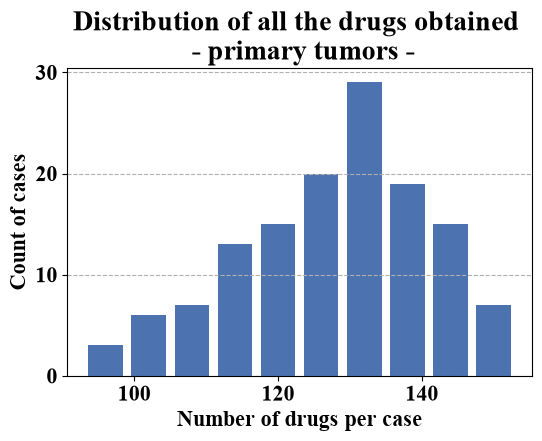

In [11]:
#plot the distribution for all drugs obtained - primary tumor
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 16
plt.rcParams['font.weight'] = 'bold'
plt.figure(figsize=(6,4))
plt.hist(df_all_primary_drugs, bins=10, color="#4C72B0", alpha=1, rwidth=0.8)
plt.xlabel("Number of drugs per case",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.ylabel("Count of cases",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.title("Distribution of all the drugs obtained \n - primary tumors -",fontsize=20, fontfamily='Times New Roman', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=1)

plt.savefig(str(save_path)+"/all_primary_drugs.eps", format='eps', dpi=500, bbox_inches='tight')
plt.show()

In [12]:
# find the number of drugs that can influence more than 10 controlled proteins (primary tumors)
df_primary_10 = summary_df[
    (summary_df["Patient"].isin(utils.list_primary)) &
    (summary_df["Patient proteins length"] >= 10)
]["Patient"].value_counts()

df_primary_10

Patient
b004e38d-f48c-49f9-a027-4a702fbaf107    33
19f1375f-51f2-4f4c-88fe-6fc84c37e5b6    29
90629e6e-2e1e-4f31-884a-6bca2c24ce11    25
3fca2c7c-2541-418d-8f45-2a48814ca574    24
ab5f9e4e-ff6a-4353-83f4-5ffddca0050a    24
                                        ..
0f12d09f-f512-4a6a-95e2-c8942488f2ff     3
681955cd-356d-4e64-924b-b0381e3c12bc     3
a3e5cda5-f468-48f3-92fa-864b8bbbecdc     3
06227615-f651-462b-948f-c305ba369efa     2
bcdc68db-c874-4097-9c46-b06e331caaf5     2
Name: count, Length: 134, dtype: int64

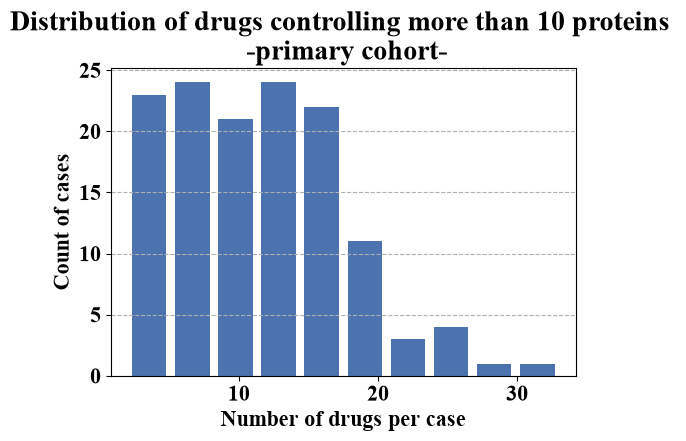

In [13]:
#plot the distribution for drugs that are able to control more than 10 essential proteins
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 16
plt.rcParams['font.weight'] = 'bold'
plt.figure(figsize=(6,4))
plt.hist(df_primary_10, bins=10, color="#4C72B0", alpha=1, rwidth=0.8)
plt.xlabel("Number of drugs per case",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.ylabel("Count of cases",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.title("Distribution of drugs controlling more than 10 proteins \n -primary cohort-",fontsize=20, fontfamily='Times New Roman', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.savefig(str(save_path)+"/primary_drugs_ab10.eps", format="eps",dpi=500, bbox_inches='tight')
plt.show()

In [14]:
# for recurrent tumor identify the number of drugs per case
df_all_recurrent = summary_df[summary_df["Patient"].isin(utils.list_recurrent)]["Patient"].value_counts()
df_all_recurrent

Patient
c12052d7-f5ae-4fd5-a36b-ac0ce21179a6    149
0317a370-6a1e-44bd-bfd0-81fd06ec56fb    144
b4919075-90a9-4c8a-82a0-a0b5f9944ad3    142
6dfd7934-3161-4384-be4d-93b14080ece8    138
f8e7cbd2-b54a-4f30-8fc1-a5c80bfad8b6    138
ddd4c4a7-6057-4244-aa4d-ccffe6e1c95a    134
928160c7-f711-4b23-832c-8c12aea9fe85    129
57c3b272-7dcb-4937-83c1-02a3694e701f    125
fe179a60-5e81-48c1-b437-7c38ed910ba8    124
d44d370d-d86e-4006-9530-ab3442cb2848    123
f0f7d061-ace0-4dbd-90ec-df8f5985a7a2    120
8223f42b-434d-4966-a123-3b8a947884bc    113
1142d18f-9cd9-41b4-a9f2-975730cb713a     97
Name: count, dtype: int64

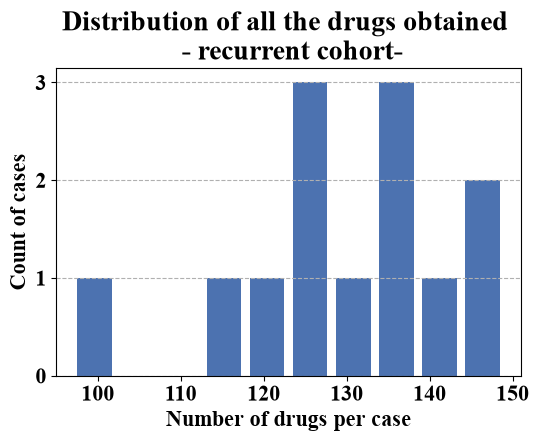

In [15]:
#plot the distribution of the drugs obtained for the recurrent group
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 16
plt.rcParams['font.weight'] = 'bold'
plt.figure(figsize=(6,4))
plt.hist(df_all_recurrent, bins=10, color="#4C72B0", alpha=1, rwidth=0.8)
#plt.hist(sizes, bins=range(1, max(sizes)+2), color="#4C72B0", alpha=0.7, rwidth=0.8)
plt.xlabel("Number of drugs per case",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.ylabel("Count of cases",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.title("Distribution of all the drugs obtained \n - recurrent cohort-",fontsize=20, fontfamily='Times New Roman', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.savefig(str(save_path)+"/all_recurrent_drugs.eps", format='eps',dpi=500, bbox_inches='tight')
plt.show()

In [16]:
# find the number of drugs that can influence more than 10 controlled proteins (recurrent tumors)
df_recurrent_10 = summary_df[
    (summary_df["Patient"].isin(utils.list_recurrent)) &
    (summary_df["Patient proteins length"] >= 10)
]["Patient"].value_counts()
df_recurrent_10

Patient
1142d18f-9cd9-41b4-a9f2-975730cb713a    24
0317a370-6a1e-44bd-bfd0-81fd06ec56fb    21
928160c7-f711-4b23-832c-8c12aea9fe85    21
c12052d7-f5ae-4fd5-a36b-ac0ce21179a6    18
8223f42b-434d-4966-a123-3b8a947884bc    16
ddd4c4a7-6057-4244-aa4d-ccffe6e1c95a    13
f0f7d061-ace0-4dbd-90ec-df8f5985a7a2    10
f8e7cbd2-b54a-4f30-8fc1-a5c80bfad8b6     8
57c3b272-7dcb-4937-83c1-02a3694e701f     7
6dfd7934-3161-4384-be4d-93b14080ece8     6
d44d370d-d86e-4006-9530-ab3442cb2848     6
fe179a60-5e81-48c1-b437-7c38ed910ba8     6
b4919075-90a9-4c8a-82a0-a0b5f9944ad3     5
Name: count, dtype: int64

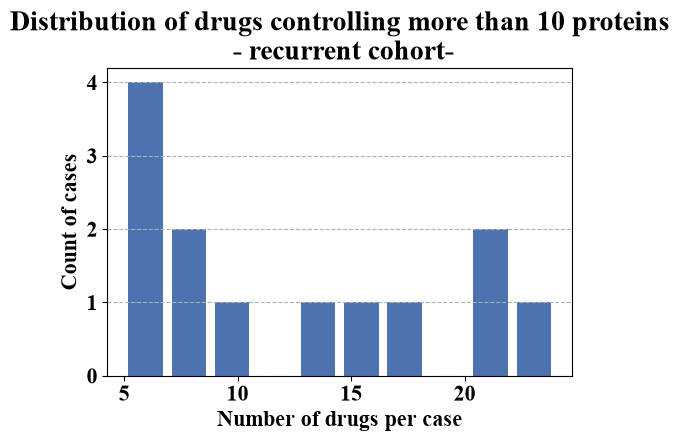

In [17]:
# distribution of drugs controlling more than 10 proteins- recurrent cohort
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 16
plt.rcParams['font.weight'] = 'bold'
plt.figure(figsize=(6,4))
plt.hist(df_recurrent_10, bins=10, color="#4C72B0", alpha=1, rwidth=0.8)
#plt.hist(sizes, bins=range(1, max(sizes)+2), color="#4C72B0", alpha=0.7, rwidth=0.8)
plt.xlabel("Number of drugs per case",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.ylabel("Count of cases",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.title("Distribution of drugs controlling more than 10 proteins\n - recurrent cohort-",fontsize=20, fontfamily='Times New Roman', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.savefig(str(save_path)+"/recurrent_drugs_ab10.eps",format="eps", dpi=500, bbox_inches='tight')
plt.show()